# Cohort quality control

This notebook reads what the pipeline recorded. It computes nothing of its own. Run `python data/download_data.py` and then `python analysis/run_all.py` before opening it.

The question the notebook answers is whether the images in the cohort can be pooled: what produced them, whether the pixel grid is stable, and whether the headers still identify anyone.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image, display

from src import config
from src.s99_utils import Metrics

pd.set_option("display.width", 110)
pd.set_option("display.max_rows", 60)

metrics = Metrics()


def table(name):
    return pd.read_csv(config.RESULTS / (name + ".csv"))


def figure(name):
    display(Image(filename=str(config.FIGURES / name)))


## What the cohort contains

The manifest fixes which patients and which series were downloaded. Every series carries the same license.

In [2]:
manifest = pd.read_csv(config.MANIFEST)
print("patients", manifest["patient_id"].nunique())
print("series  ", len(manifest))
print("instances", int(manifest["instance_count"].sum()))
print("size, GB ", round(manifest["size_mb"].sum() / 1024, 2))
manifest.groupby("role")[["series_uid"]].count().rename(columns={"series_uid": "series"})

patients 41
series   276
instances 54673
size, GB  8.86


,series
role,
image,235
segmentation,41


## Acquisition equipment

Signal intensity in magnetic resonance depends on the scanner and the sequence, so the equipment present bounds what a model trained on the cohort can be expected to transfer to.

In [3]:
table("scanner_inventory")

,manufacturer,model_name,series,patients
0,SIEMENS,TrioTim,235,41


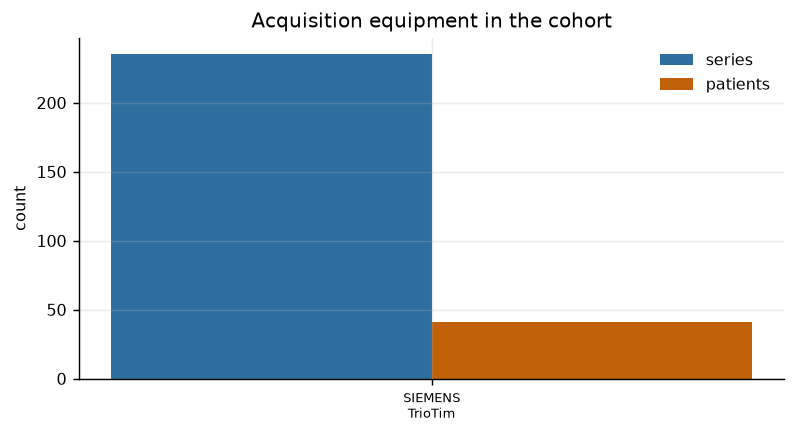

In [4]:
figure("fig01_scanner_inventory.png")

## Series types

The studies hold diffusion and perfusion acquisitions alongside the structural series. They are counted here and excluded from the labeled task, because their contrast is not the contrast the segmentation was drawn on.

In [5]:
inventory = table("series_inventory")
inventory["series_desc"].value_counts().head(20).to_frame("series")

,series
series_desc,
Axial T2 tse: Processed_CaPTk,33
t1 axial: Processed_CaPTk,30
t2_Flair_axial: Processed_CaPTk,30
t1 axial stealth-post : Processed_CaPTk,30
ep2d_DTI_30dir,25
ep2d_perf BOLUS,12
ep2d_perf 12 CC BOLUS,10
T2 SAG SPACE: Processed_CaPTk,8
ep2d_DTI_30dir_T,7


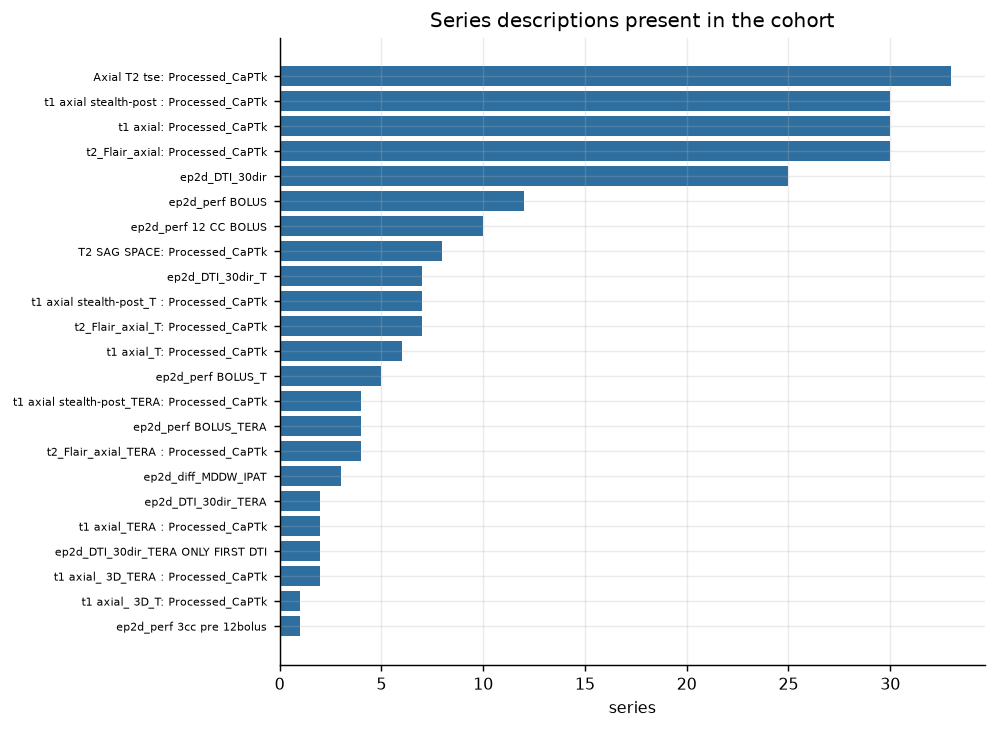

In [6]:
figure("fig02_series_descriptions.png")

## Image grid stability

A patient whose first and last series differ in row or column count cannot be stacked into one array without resampling.

In [7]:
findings = table("qc_findings")
print("patients whose first and last series differ in size:",
      int(metrics.number("qc_patients_with_dimension_change")))
print("patients holding more than one grid:",
      int(metrics.number("qc_patients_with_multiple_grids")))
findings[(findings["check"] == "first_last_dimensions") & (findings["flagged"] == 1)]

patients whose first and last series differ in size: 31
patients holding more than one grid: 41


,check,subject,detail,flagged
3,first_last_dimensions,UPENN-GBM-00020,896x896 then 256x192,1
5,first_last_dimensions,UPENN-GBM-00048,896x896 then 128x128,1
6,first_last_dimensions,UPENN-GBM-00049,256x192 then 896x896,1
7,first_last_dimensions,UPENN-GBM-00050,128x128 then 256x192,1
8,first_last_dimensions,UPENN-GBM-00062,128x128 then 896x896,1
10,first_last_dimensions,UPENN-GBM-00085,128x128 then 896x896,1
12,first_last_dimensions,UPENN-GBM-00142,256x192 then 256x208,1
15,first_last_dimensions,UPENN-GBM-00224,128x128 then 256x192,1
16,first_last_dimensions,UPENN-GBM-00226,320x256 then 256x192,1
17,first_last_dimensions,UPENN-GBM-00231,128x128 then 256x192,1


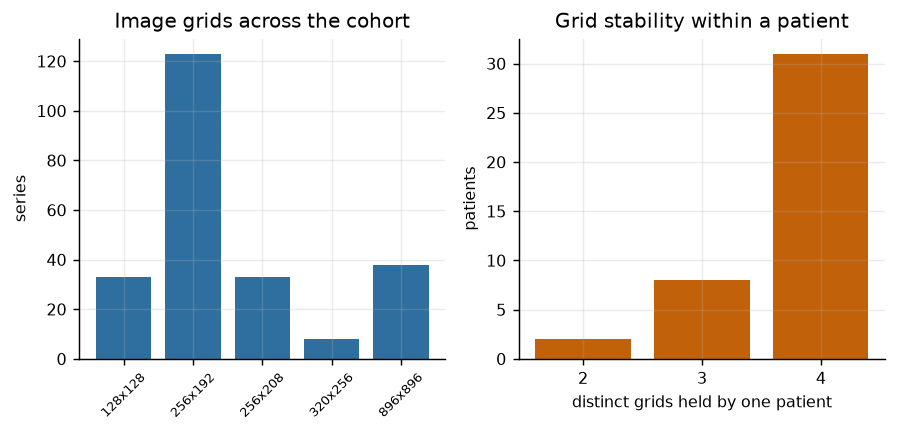

In [8]:
figure("fig03_image_grids.png")

## Pixel encoding

Photometric interpretation decides whether a high stored value is bright or dark. A cohort mixing the two would train a model on inverted images without any error being raised.

In [9]:
findings[findings["check"].isin(["photometric_interpretation",
                                 "bits_allocated", "modality",
                                 "within_series_constant"])]

,check,subject,detail,flagged
1,modality,MR,235 series,0
84,photometric_interpretation,MONOCHROME2,235 series,0
85,bits_allocated,16,235 series,0
96,within_series_constant,bits_allocated,0 series carry more than one value,0
97,within_series_constant,cols,0 series carry more than one value,0
98,within_series_constant,manufacturer,0 series carry more than one value,0
99,within_series_constant,model_name,0 series carry more than one value,0
100,within_series_constant,photometric_interpretation,0 series carry more than one value,0
101,within_series_constant,rows,0 series carry more than one value,0


## De-identification

One instance from every series is checked against the tags that carry identity. Anything populated here would be a reason to stop.

In [10]:
audit = table("phi_audit")
summary = {
    "series audited": len(audit),
    "identifier tags populated": int(
        metrics.number("phi_series_with_populated_identifier_tags")),
    "burned-in annotation declared": int(
        metrics.number("phi_burned_in_annotation_yes")),
    "patient identifiers off the collection form": int(
        metrics.number("phi_patient_id_non_conforming")),
    "series carrying private tags": int(
        metrics.number("phi_series_with_private_tags")),
    "largest private tag count": int(metrics.number("phi_max_private_tags")),
}
pd.Series(summary).to_frame("count")

,count
series audited,276
identifier tags populated,0
burned-in annotation declared,0
patient identifiers off the collection form,0
series carrying private tags,235
largest private tag count,43


## The label and the image share a coordinate system

The segmentation is stored on its own grid, whose in-plane orientation is the negative of the image orientation. Resampling through the patient coordinate system puts the two on one grid, and the overlay is the check that it worked.

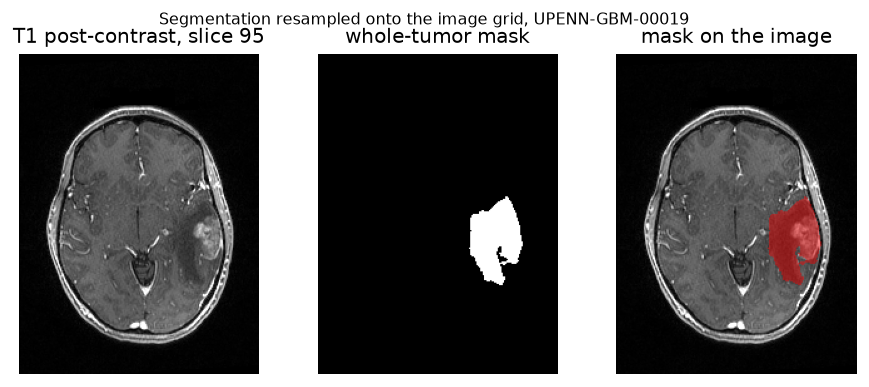

In [11]:
figure("fig04_mask_alignment.png")